# JSE Sector Momentum Strategy
## Stage 5 — Backtesting

### Objective
Test the strategy profitability against historical data and evaluate the key profitability and risk metrics.

### Input Files
- data/jse_sector_momentum_signal.csv — the sector to invest in each month
- data/jse_sector_monthly_log_returns_2019_2026.csv — monthly log returns
- data/jse_sector_prices_clean_2019_2026.csv — daily prices for ALSI benchmark

### Steps
1. Load ALSI, signal and monthly returns files
2. Compute ALSI (Benchmark) monthly returns over the study period
3. Compute strategy returns and visualise cumulative returns against the ALSI
4. Compute Performance Metrics
5. Interpretation — Backtest Results

### Key Findings
On an annual retun basis the momentum strategy was more superious than the alsi but it was nmore resikier and it undeperformed for ye\at from 20220 to 2025. Bulk of the return was generated in 2024 to 2026.

### Output
    Strategy performance

### Next Step
Stage 6- Consolidate results and write report

### Results Interpretation

As a well-known feature, the JSE has momentum. The tested 12-1 momentum strategy from 2020 to 2026 produced an annual return of 15.78% against the ALSI which returned 11.93% over the same period, representing 3.85% excess return over the benchmark. However, the bulk of that return was generated from 2024 to 2026, and the strategy only surpassed the ALSI in late 2025. In all other years after the COVID recovery in 2021, it kept returning to its same level as at the start of 2020.

Whilst the returns of the strategy are high, they came at the cost of higher risk, experiencing volatility of 24.88% compared to 16.50% for the ALSI, and a maximum drawdown of 21.34% compared to 16.25% for the ALSI. It took an extra 8.38% more volatility and 5.09% more maximum drawdown to generate the extra 3.85% return, which demonstrates that the strategy introduced more risk than it brought return. The Sharpe ratio confirms this — 0.63 for the strategy versus 0.72 for the ALSI. By simply leveraging the ALSI, investors would be able to earn more without taking on the additional risk of the strategy.

The strategy did not perform well from 2020 to 2025 and only surpassed the ALSI in late 2025. During the COVID crash the strategy fell slightly more than the ALSI, demonstrating the well-known characteristic that momentum strategies struggle when all assets move in the same direction. When recovery came in late 2020 into 2022 the strategy also recovered, but once that momentum died the strategy started to underperform again. The cumulative return picture shows that unless there is sustained momentum in the market the strategy performs poorly, and it was the commodity boom starting in 2024 that drove the late outperformance.

The strategy would suit an investor willing to endure long periods of underperformance before recovering once the market develops sustained momentum. It is worth noting that Resources as a standalone index outperformed the strategy significantly, suggesting the rotation mechanism added complexity without proportional reward during this period.

The strategy also lacks a mechanism to exit the market when momentum is too weak across all sectors. Adding a cash filter is a logical improvement. However, the timing paradox remains — by the time momentum is observed it may already be fading.

### Step 1: Load signal and monthly returns files

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [20]:
sector_monthly_returns = pd.read_csv("data/jse_sector_monthly_log_returns_2019_2026.csv", index_col=0, parse_dates=True)
print("Sector Monthly Returns")
print(sector_monthly_returns.head())
sector_momentum_signal = pd.read_csv("data/jse_sector_momentum_signal.csv", index_col=0, parse_dates=True)
print("Sector Momentum Signal")
print(sector_momentum_signal.head())
alsi_daily_prices = pd.read_csv("data/jse_alsi_prices_clean_2019_2026.csv", index_col=0, parse_dates=True)
print("ALSI Daily Prices")
print(alsi_daily_prices.head())

Sector Monthly Returns
            Financials  Resources  Industrials  Consumer Goods
Date                                                          
2019-02-28   -0.021239   0.087303    -0.024094        0.118959
2019-03-31   -0.046531   0.030868    -0.058845        0.014972
2019-04-30    0.044953  -0.023175     0.057251       -0.006261
2019-05-31   -0.025558  -0.052975    -0.039682       -0.021071
2019-06-30    0.011440   0.096746    -0.044402        0.076821
Sector Momentum Signal
                         0
Date                      
2020-01-31       Resources
2020-02-29       Resources
2020-03-31  Consumer Goods
2020-04-30  Consumer Goods
2020-05-31  Consumer Goods
ALSI Daily Prices
                   Close          High           Low          Open  Volume
Date                                                                      
2019-01-02  51264.058594  52736.859375  50907.449219  52736.859375       0
2019-01-03  51669.941406  51870.898438  51135.199219  51264.058594       0
2019-0

In [ ]:
# Rename the signal column to "Signal" for clarity
sector_momentum_signal = sector_momentum_signal.rename(columns={'0': 'Signal'})
print(sector_momentum_signal.head())

                    Signal
Date                      
2020-01-31       Resources
2020-02-29       Resources
2020-03-31  Consumer Goods
2020-04-30  Consumer Goods
2020-05-31  Consumer Goods


## Step 2: Compute ALSI (Benchmark) monthly returns over the study period

In [22]:
# Compute ALSI monthly returns
alsi_monthly_index_close = alsi_daily_prices["Close"].resample("ME").last()
alsi_monthly_returns = np.log(alsi_monthly_index_close / alsi_monthly_index_close.shift(1)).dropna()
print("ALSI Monthly Returns")
print(alsi_monthly_returns.head())


ALSI Monthly Returns
Date
2019-02-28    0.033506
2019-03-31    0.008189
2019-04-30    0.035934
2019-05-31   -0.050423
2019-06-30    0.044862
Freq: ME, Name: Close, dtype: float64


### Step 3 — Compute Strategy Returns and Visualise Cumulative Returns Against the ALSI

For each month, select the return of the sector indicated by the signal from the previous month. This one month lag reflects the real world execution — signal generated at end of month T, position taken in month T+1.

In [23]:
# Shift signal forward by one month to reflect execution lag
signal_lagged = sector_momentum_signal["Signal"].shift(1)

# For each month select the return of the signalled sector
strategy_returns = pd.Series(index=sector_monthly_returns.index, dtype=float)

for date in sector_monthly_returns.index:
    sector = signal_lagged.get(date)
    if pd.notna(sector) and sector in sector_monthly_returns.columns:
        strategy_returns[date] = sector_monthly_returns.loc[date, sector]

# Drop months with no signal
strategy_returns = strategy_returns.dropna()

print(f"Strategy returns: {len(strategy_returns)} months")
print(strategy_returns.head())    

Strategy returns: 75 months
Date
2020-02-29   -0.123103
2020-03-31   -0.150959
2020-04-30    0.090503
2020-05-31   -0.027404
2020-06-30    0.048330
dtype: float64


In [24]:
#Align ALSI to strategy range
alsi_aligned = alsi_monthly_returns.reindex(strategy_returns.index).dropna()

# Compute cumulative returns
strategy_cumulative = np.exp(strategy_returns.cumsum())
alsi_cumulative = np.exp(alsi_aligned.cumsum())


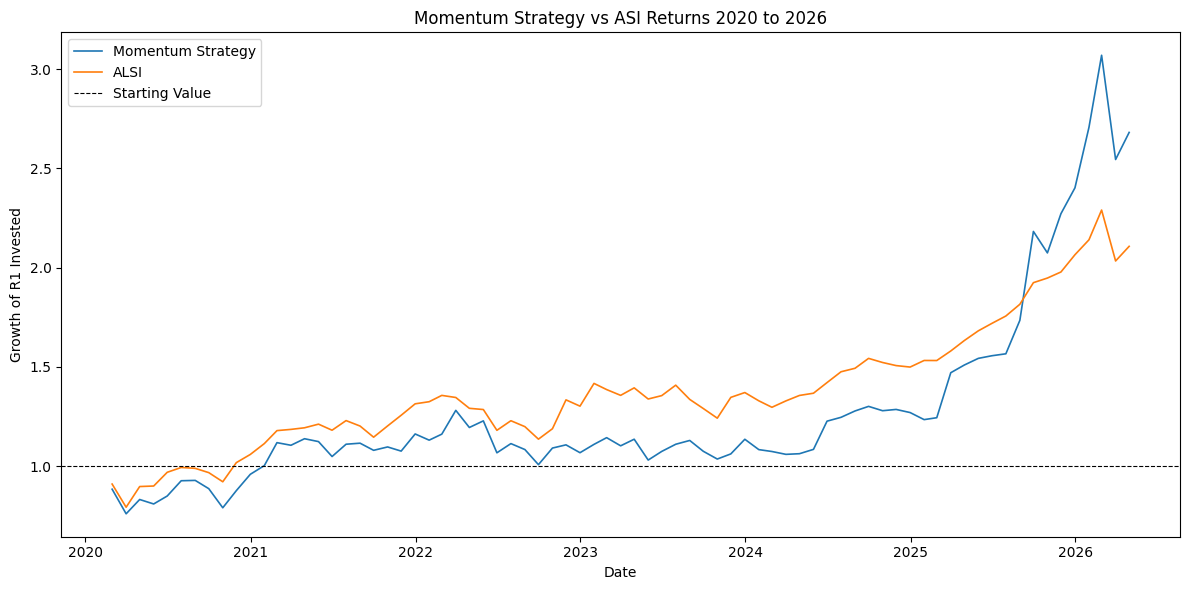

In [25]:
# Plot all sectors on one chart
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(strategy_cumulative.index, strategy_cumulative, linewidth=1.2, label='Momentum Strategy')
ax.plot(alsi_cumulative.index, alsi_cumulative, linewidth=1.2, label='ALSI')

ax.axhline(y=1.0, color='black', linestyle='--', linewidth=0.8, label='Starting Value')
ax.set_title("Momentum Strategy vs ASI Returns 2020 to 2026")
ax.set_ylabel("Growth of R1 Invested")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.show()

### Step 4 — Compute Performance Metrics

Calculate annualised return, annualised volatility, Sharpe ratio, and maximum drawdown for both the strategy and the ALSI benchmark.

In [26]:
# Annuallized Return
alsi_annualized_return = alsi_aligned.mean() * 12
strategy_annualized_return = strategy_returns.mean() * 12
print(f"ALSI Annualized Return: {alsi_annualized_return:.2%}")
print(f"Strategy Annualized Return: {strategy_annualized_return:.2%}")

# Annuallized Volatility
alsi_annualized_vol = alsi_aligned.std() * np.sqrt(12)
strategy_annualized_vol = strategy_returns.std() * np.sqrt(12)
print(f"ALSI Annualized Volatility: {alsi_annualized_vol:.2%}")
print(f"Strategy Annualized Volatility: {strategy_annualized_vol:.2%}")

# Sharpe Ratio (assuming risk-free rate is 0)
alsi_sharpe = alsi_annualized_return / alsi_annualized_vol
strategy_sharpe = strategy_annualized_return / strategy_annualized_vol
print(f"ALSI Sharpe Ratio: {alsi_sharpe:.2f}")
print(f"Strategy Sharpe Ratio: {strategy_sharpe:.2f}")

# Maximum Drawdown
alsi_rolling_max = alsi_cumulative.cummax()
alsi_drawdown = (alsi_cumulative - alsi_rolling_max) / alsi_rolling_max
alsi_max_drawdown = alsi_drawdown.min()

# Calculate strategy drawdown
strategy_rolling_max = strategy_cumulative.cummax()
strategy_drawdown = (strategy_cumulative - strategy_rolling_max) / strategy_rolling_max
strategy_max_drawdown = strategy_drawdown.min()
print(f"ALSI Max Drawdown: {alsi_max_drawdown:.2%}")
print(f"Strategy Max Drawdown: {strategy_max_drawdown:.2%}")

ALSI Annualized Return: 11.93%
Strategy Annualized Return: 15.78%
ALSI Annualized Volatility: 16.50%
Strategy Annualized Volatility: 24.88%
ALSI Sharpe Ratio: 0.72
Strategy Sharpe Ratio: 0.63
ALSI Max Drawdown: -16.25%
Strategy Max Drawdown: -21.34%


In [27]:
# Create a summary DataFrame for the performance metrics
performance_summary_formatted = pd.DataFrame({
    "Momentum Strategy": [
        f"{strategy_annualized_return:.2%}",
        f"{strategy_annualized_vol:.2%}",
        f"{strategy_sharpe:.2f}",
        f"{strategy_max_drawdown:.2%}"
    ],
    "ALSI Benchmark": [
        f"{alsi_annualized_return:.2%}",
        f"{alsi_annualized_vol:.2%}",
        f"{alsi_sharpe:.2f}",
        f"{alsi_max_drawdown:.2%}"
    ]
}, index=["Annual Return", "Annual Volatility", "Sharpe Ratio", "Max Drawdown"])

print(performance_summary_formatted)

                  Momentum Strategy ALSI Benchmark
Annual Return                15.78%         11.93%
Annual Volatility            24.88%         16.50%
Sharpe Ratio                   0.63           0.72
Max Drawdown                -21.34%        -16.25%


### Stage 5 Interpretation — Backtest Results

The momentum strategy produced an annual return of 15.78% against the ALSI which returned 11.93% over the same period, representing 3.85% excess return over the benchmark.

At face value the strategy's returns are superior, however they came at a volatility of 24.88% compared to 16.50% for the ALSI. This means it took an extra 8.38% more volatility and 5.09% more maximum drawdown to generate the extra 3.85% return, which demonstrates that the strategy introduced more risk than it brought return. The Sharpe ratio confirms this — 0.63 for the strategy versus 0.72 for the ALSI.

The strategy did not perform well from 2020 to 2025 and only surpassed the ALSI in late 2025. During the COVID crash the strategy fell slightly more than the ALSI, demonstrating the well known characteristic that momentum strategies struggle when all assets move in the same direction. When recovery came in late 2020 into 2022 the strategy also recovered, but once that momentum died the strategy started to underperform again. The cumulative return picture shows that unless there is sustained momentum in the market the strategy does poorly, and it was the commodity boom starting in 2024 that drove the late outperformance.

The strategy would suit an investor willing to endure long periods of underperformance before recovering once the market develops sustained momentum. It is worth noting that Resources as a standalone index outperformed the strategy significantly — suggesting the rotation mechanism added complexity without proportional reward during this period.

The strategy also lacks a mechanism to exit the market when momentum is too weak across all sectors. Adding a cash filter is a logical improvement, however the timing paradox remains — by the time momentum is observed it may already be fading.
